In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score


from sklearn.ensemble import RandomForestClassifier


from sklearn.preprocessing import StandardScaler


from sklearn.impute import SimpleImputer


from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)


import joblib

In [ ]:

df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df["Outcome"].value_counts())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose      

In [ ]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("Missing values after replacing 0s:")
print(df.isnull().sum())

Missing values after replacing 0s:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
imputer = SimpleImputer(strategy="median")
df[cols_with_zeros] = imputer.fit_transform(df[cols_with_zeros])

print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (614, 8)
Testing size: (154, 8)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

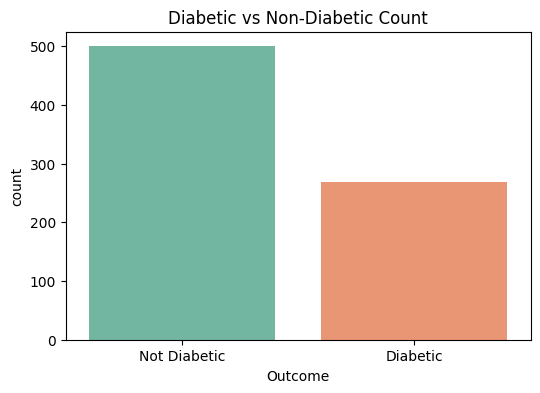

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df, palette="Set2")
plt.title("Diabetic vs Non-Diabetic Count")
plt.xticks([0,1], ["Not Diabetic", "Diabetic"])
plt.savefig("plot1_class_distribution.png")
plt.show()

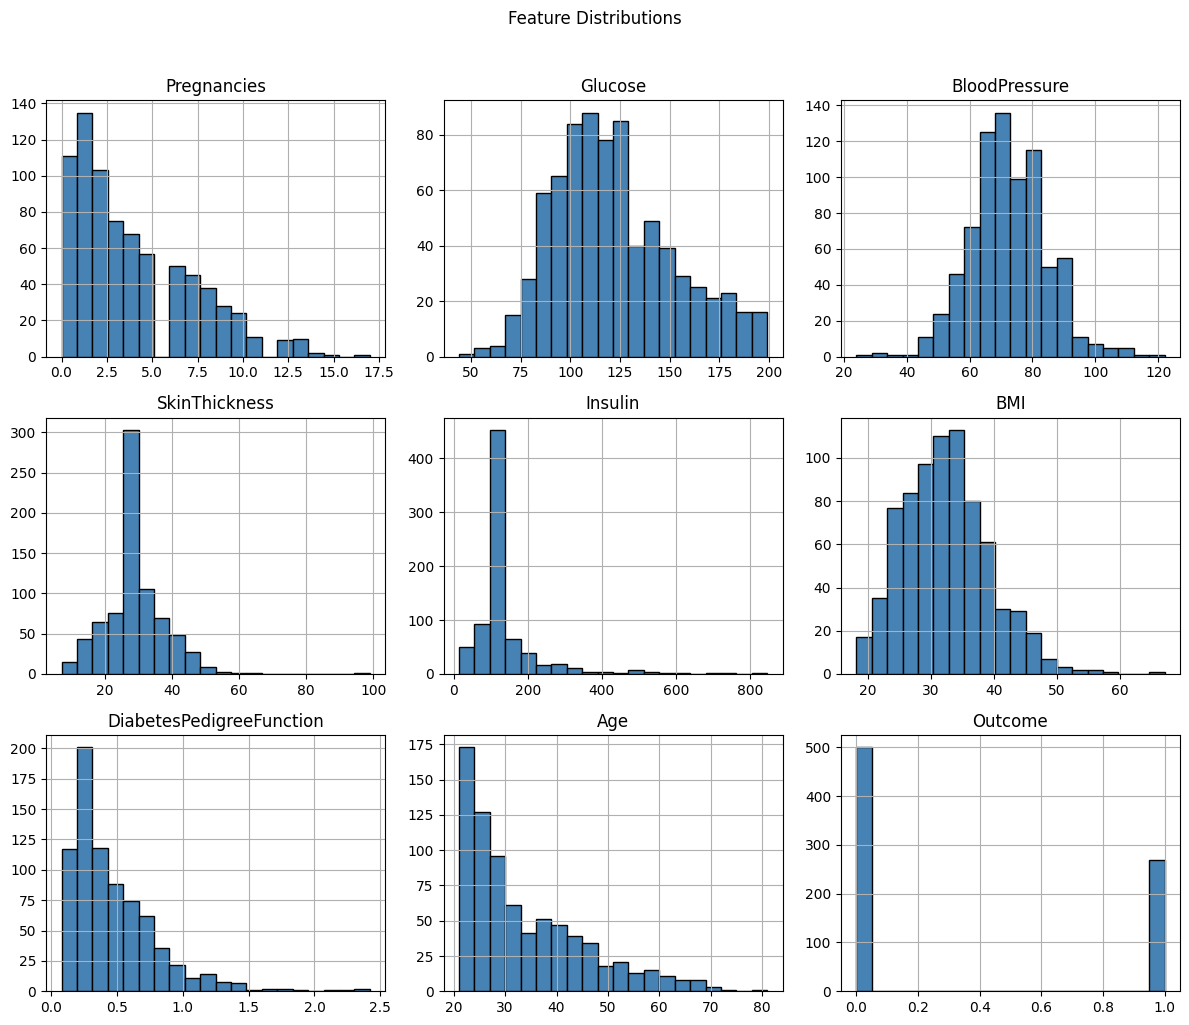

In [ ]:
df.hist(figsize=(12,10), bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig("plot2_feature_distributions.png")
plt.show()

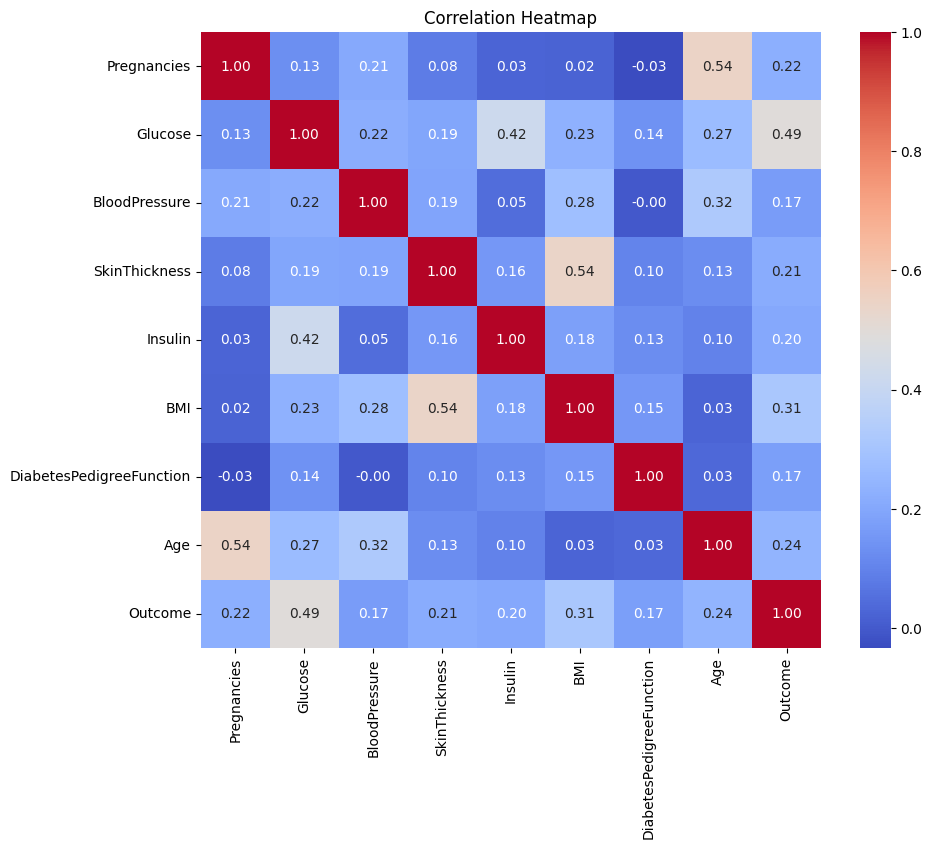

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("plot3_heatmap.png")
plt.show()

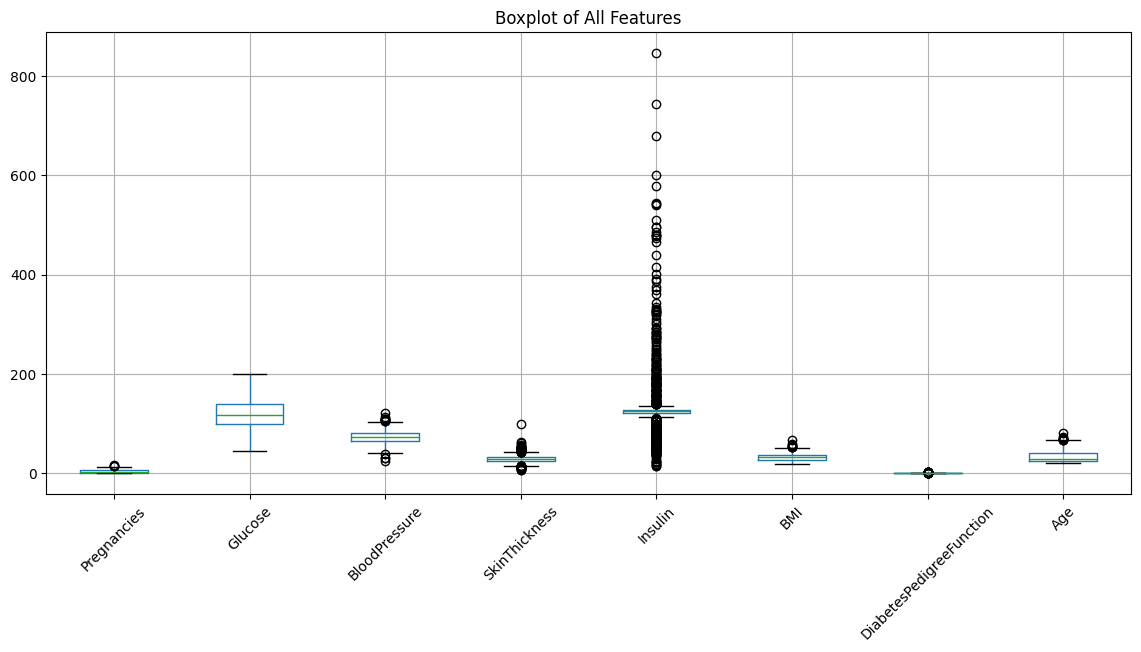

In [ ]:
plt.figure(figsize=(14,6))
df.drop("Outcome", axis=1).boxplot()
plt.title("Boxplot of All Features")
plt.xticks(rotation=45)
plt.savefig("plot4_boxplot.png")
plt.show()

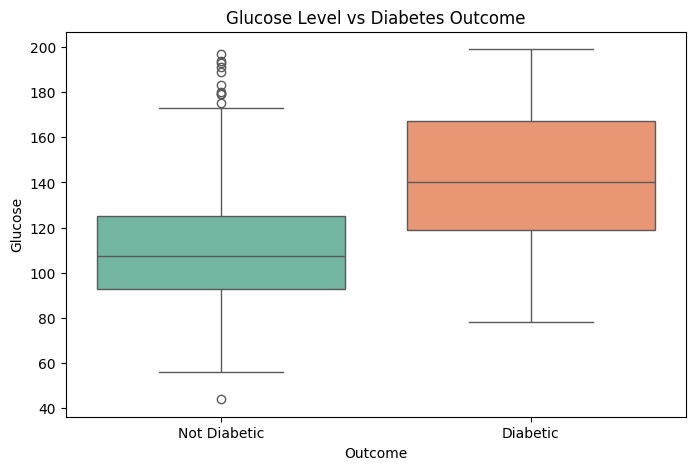

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Outcome", y="Glucose", data=df, palette="Set2")
plt.title("Glucose Level vs Diabetes Outcome")
plt.xticks([0,1], ["Not Diabetic", "Diabetic"])
plt.savefig("plot5_glucose_vs_outcome.png")
plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:

rf_model.fit(X_train, y_train)


print("✅ Model training complete!")

✅ Model training complete!


In [ ]:

y_pred = rf_model.predict(X_test)


y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}


grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("✅ Best settings found:")
print(grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
✅ Best settings found:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:

best_model = grid_search.best_estimator_


y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("✅ Best model predictions done!")


✅ Best model predictions done!


In [ ]:
print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)


accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy  : {accuracy * 100:.2f}%")


f1 = f1_score(y_test, y_pred_best)
print(f"F1 Score  : {f1:.4f}")


roc_auc = roc_auc_score(y_test, y_pred_proba_best)
print(f"ROC-AUC   : {roc_auc:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=["Not Diabetic", "Diabetic"]))

       MODEL EVALUATION RESULTS
Accuracy  : 75.32%
F1 Score  : 0.6275
ROC-AUC   : 0.8081

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.79      0.84      0.82       100
    Diabetic       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



Text(0.5, 500.7222222222223, 'Predicted')

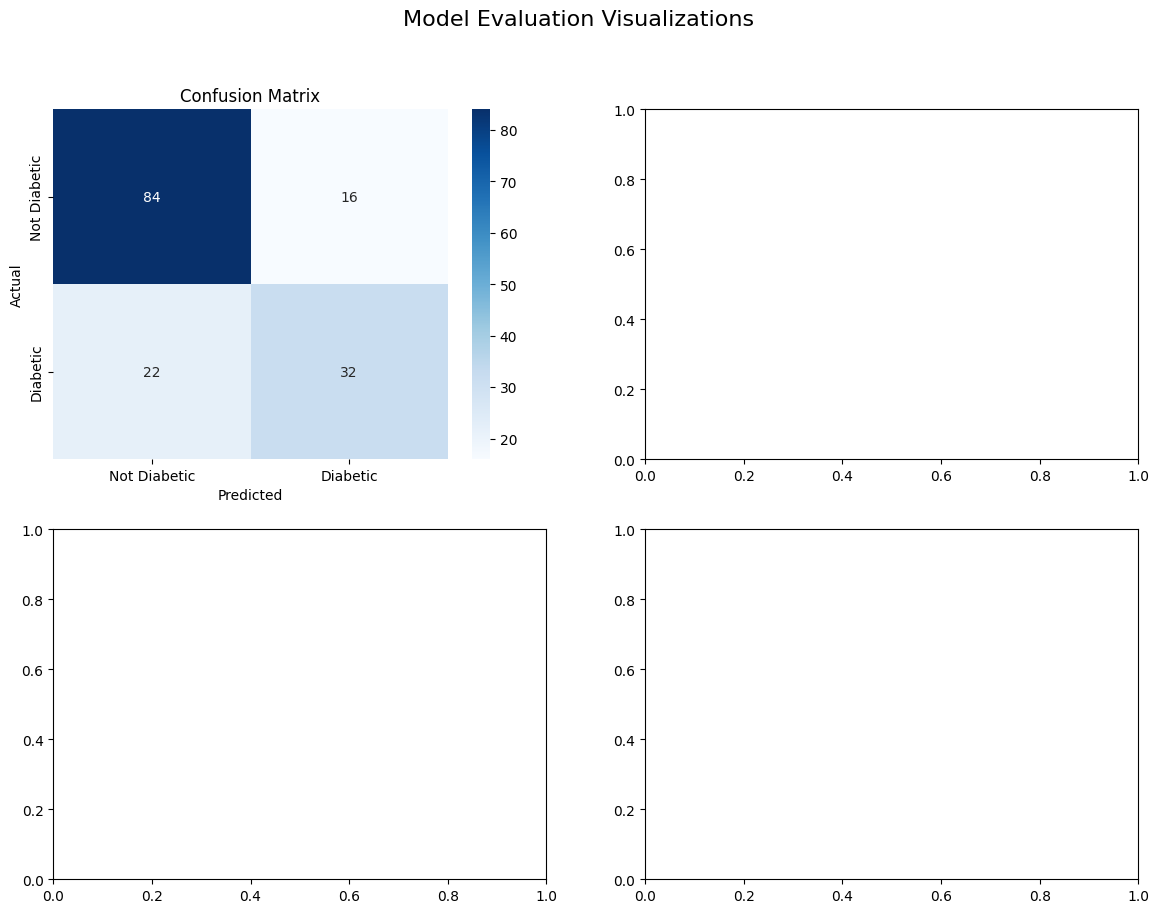

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Evaluation Visualizations", fontsize=16)


cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Diabetic", "Diabetic"],
            yticklabels=["Not Diabetic", "Diabetic"],
            ax=axes[0,0])
axes[0,0].set_title("Confusion Matrix")
axes[0,0].set_ylabel("Actual")
axes[0,0].set_xlabel("Predicted")

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
axes[0,1].plot(fpr, tpr, color="darkorange",
               label=f"ROC Curve (AUC = {roc_auc:.2f})")
axes[0,1].plot([0,1], [0,1], color="navy", linestyle="--",
               label="Random Guess")
axes[0,1].set_title("ROC Curve")
axes[0,1].set_xlabel("False Positive Rate")
axes[0,1].set_ylabel("True Positive Rate")
axes[0,1].legend()

In [ ]:
importances = best_model.feature_importances_
feature_names = df.drop("Outcome", axis=1).columns
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

sns.barplot(x="Importance", y="Feature",
            data=feat_df, palette="viridis", ax=axes[1,0])
axes[1,0].set_title("Feature Importance")

Text(0.5, 1.0, 'Feature Importance')

In [ ]:
results_df = pd.DataFrame({
    "Type": ["Actual Diabetic", "Actual Not Diabetic",
             "Predicted Diabetic", "Predicted Not Diabetic"],
    "Count": [sum(y_test==1), sum(y_test==0),
              sum(y_pred_best==1), sum(y_pred_best==0)]
})
sns.barplot(x="Type", y="Count",
            data=results_df, palette="Set2", ax=axes[1,1])
axes[1,1].set_title("Actual vs Predicted Counts")
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("plot6_evaluation.png", bbox_inches="tight")
plt.show()
print("✅ All evaluation graphs saved!")

<Figure size 640x480 with 0 Axes>

✅ All evaluation graphs saved!


In [ ]:
import joblib


joblib.dump(best_model, "diabetes_rf_model.pkl")
print("✅ Model saved as diabetes_rf_model.pkl")


joblib.dump(scaler, "scaler.pkl")
print("✅ Scaler saved as scaler.pkl")


loaded_model = joblib.load("diabetes_rf_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")


new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])


new_patient_scaled = loaded_scaler.transform(new_patient)
prediction = loaded_model.predict(new_patient_scaled)
probability = loaded_model.predict_proba(new_patient_scaled)[0][1]

print(f"\n🩺 Prediction: {'Diabetic' if prediction[0]==1 else 'Not Diabetic'}")
print(f"📊 Probability of Diabetes: {probability*100:.1f}%")

✅ Model saved as diabetes_rf_model.pkl
✅ Scaler saved as scaler.pkl

🩺 Prediction: Not Diabetic
📊 Probability of Diabetes: 44.2%
